In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

In [41]:
# Malgun Gothic 경로 지정
font_path = "C:/Windows/Fonts/malgun.ttf"
font_prop = fm.FontProperties(fname=font_path)
mpl.rcParams['font.family'] = font_prop.get_name()

# 마이너스 깨짐 방지
mpl.rcParams['axes.unicode_minus'] = False

In [2]:
from prophet import Prophet
from croston import croston
from darts.models import VARIMA
from darts import TimeSeries
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

- tqdm은 반복문 실행 시 진행 상태(progress bar) 를 시각적으로 보여주는 Python 라이브러리
- 시간이 오래 걸리는 작업을 할 때 진행률을 쉽게 파악할 수 있다.

***

## 데이터 로드

In [3]:
full_data = pd.read_csv('../data/full_date_data_for_MTSF.csv', encoding = 'cp949')

### date 컬럼을 datetime으로 변경해 시계열 데이터로 사용

In [4]:
full_data['date'] = pd.to_datetime(full_data['date'])

## 데이터 조회

In [5]:
full_data.head(3)

,date,daily_quantity_실리콘_계란찜기(소),daily_quantity_실리콘_뒤짐개,daily_quantity_실리콘_볶음주걱,daily_quantity_내열장갑,daily_quantity_실리콘_계란찜기(대),daily_quantity_실리콘_도마(대),daily_quantity_실리콘_냄비잡이,daily_quantity_실리콘_스테인리스집게(소),daily_quantity_오픈수납함,daily_quantity_실리콘_계란찜기(중),daily_quantity_실리콘_도마(중),daily_quantity_실리콘_멀티스푼,daily_quantity_실리콘_비누받침,daily_quantity_실리콘_스테인리스집게(대),daily_quantity_실리콘_다용도 오일브러쉬,daily_quantity_실리콘_덮개세트_샤크
0,2022-01-03,0,0,0,0,0,0,0,0,184,0,0,0,0,40,0,0
1,2022-01-04,0,0,0,10,10,40,0,0,10,0,40,0,0,1,0,0
2,2022-01-05,0,30,0,0,0,36,0,10,1,0,18,60,0,12,0,30


***

## 데이터 분할: 학습용/시험용

In [6]:
# 전체 길이 기준으로 80% 지점 계산
split_index = int(len(full_data) * 0.8)

> 0행-874행: train data
>
> 875행-1093행: test data

In [7]:
# 시계열 순서대로 split
train_df = full_data.iloc[:split_index]
test_df = full_data.iloc[split_index:]

***

## 1. Prophet
- Facebook에서 만든 시계열 예측 라이브러리
- 추세(선형/비선형 경향을 학습) + 계절성(주기적인 패턴을 캡처 (예: 주간/연간 등)) + 이벤트 효과(특별한 날의 영향 반영 가능)를 모두 분리해서 모델링
- 단변량 시계열만 가능 (따라서 각 컬럼마다 따로 예측)
- Prophet을 사용할 때는 날짜 컬럼 이름을 반드시 ds, 예측하려는 타깃 값은 y 라고 지정

### 1) 모든 컬럼 반복 예측 + 평가
- Naive 모델은 "이전 시점의 값이 다음 시점의 예측"이라고 가정

In [8]:
def prophet_forecast_evaluate(train_df, test_df, col):
    # Prophet 형식 맞추기: 날짜 컬럼이 ds, 예측할 값이 y
    df_train = train_df[['date', col]].rename(columns={'date': 'ds', col: 'y'})
    df_test = test_df[['date', col]].rename(columns={'date': 'ds', col: 'y'})

    # Prophet 모델 객체 생성 후 학습 데이터를 사용해 훈련
    model = Prophet()
    model.fit(df_train)

    # 학습이 끝나고, 예측할 날짜만 넘기면 Prophet이 해당 날짜에 대한 예측값(yhat)을 자동으로 생성
    future = df_test[['ds']]
    forecast_test = model.predict(future)

    # 예측 결과
    y_pred = forecast_test['yhat'].values # Prophet의 예측값 (yhat)
    y_true = df_test['y'].values # y_true: 테스트 데이터의 실제 관측값

    # 성능 지표
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    # Naive 모델 비교용 (shift로 한 시점 앞 값 사용)
    # .shift(1)은 데이터를 아래로 1칸 이동시킴
    # .dropna()로 맨 앞의 NaN을 제거: 길이 동일해야함
    naive_forecast = train_df[col].shift(1).dropna().values # 이전 시점의 값을 그대로 예측
    naive_actual = train_df[col][1:].values # 실제로 관측된 값, 이는 한 칸 뒤의 값들

    # Naive 기반 MASE, RMSSE 계산: Naive 모델이 어느 정도 정확한가
    mase_denom = np.mean(np.abs(naive_actual - naive_forecast))
    rmsse_denom = np.sqrt(np.mean((naive_actual - naive_forecast) ** 2))

    # 모델 성능 / Naive 성능
    mase = mae / mase_denom if mase_denom != 0 else np.nan
    rmsse = rmse / rmsse_denom if rmsse_denom != 0 else np.nan

    return forecast_test[['ds', 'yhat']], rmsse, mase


- MASE는 Prophet의 MAE를 Naive 모델의 MAE로 나눈 값
- RMSSE는 RMSE를 Naive 모델의 RMSE로 나눈 것
- Naive 모델보다 좋으면 MASE < 1, RMSSE < 1: 즉, 둘 다 낮을수록 좋은 성능이고, Naive보다 얼마나 나은지를 평가하는 지표
- mase_denom == 0이면 Naive 모델의 예측 오차가 없었다는 뜻

### 2) 예측하고 싶은 컬럼에 대해 Prophet 실행

In [9]:
# 예측하고 싶은 컬럼들의 리스트
target_cols = [col for col in train_df.columns if col.startswith('daily_quantity_')]

- daily_quantity_로 시작하는 컬럼들만 예측 대상 시계열로 보고, date나 기타 컬럼은 예측 대상이 아니라고 간주
- 데이터프레임의 모든 컬럼 순회하면서 컬럼 이름 조건 만족하는 컬럼명을 리스트로 저장

Prophet 모델을 여러 개의 시계열 컬럼(=품목)에 대해 반복 적용하고, 각각의 예측 결과 및 성능 지표(MASE, RMSSE)를 저장
- 각 품목은 개별 시계열로 보고 Prophet을 따로 학습시킨다

In [10]:
# 결과 저장
all_forecasts = [] # 예측 결과를 저장할 리스트
rmsse_results = {} # 컬럼별 RMSSE 값을 저장할 딕셔너리
mase_results = {} # 컬럼별 MASE 값을 저장할 딕셔너리

for col in target_cols: # 예측할 각 컬럼에 대해 Prophet 실행
    forecast, rmsse, mase = prophet_forecast_evaluate(train_df, test_df, col)
    forecast = forecast.rename(columns={'yhat': f'forecast_{col}'}) # Prophet의 예측 결과 컬럼은 기본적으로 yhat -> 품목 구분 위해 forecast_item1 식으로 변경
    all_forecasts.append(forecast)

    rmsse_results[col] = rmsse
    mase_results[col] = mase

14:17:03 - cmdstanpy - INFO - Chain [1] start processing
14:17:04 - cmdstanpy - INFO - Chain [1] done processing
14:17:04 - cmdstanpy - INFO - Chain [1] start processing
14:17:04 - cmdstanpy - INFO - Chain [1] done processing
14:17:04 - cmdstanpy - INFO - Chain [1] start processing
14:17:05 - cmdstanpy - INFO - Chain [1] done processing
14:17:05 - cmdstanpy - INFO - Chain [1] start processing
14:17:05 - cmdstanpy - INFO - Chain [1] done processing
14:17:05 - cmdstanpy - INFO - Chain [1] start processing
14:17:05 - cmdstanpy - INFO - Chain [1] done processing
14:17:06 - cmdstanpy - INFO - Chain [1] start processing
14:17:06 - cmdstanpy - INFO - Chain [1] done processing
14:17:06 - cmdstanpy - INFO - Chain [1] start processing
14:17:06 - cmdstanpy - INFO - Chain [1] done processing
14:17:07 - cmdstanpy - INFO - Chain [1] start processing
14:17:07 - cmdstanpy - INFO - Chain [1] done processing
14:17:07 - cmdstanpy - INFO - Chain [1] start processing
14:17:07 - cmdstanpy - INFO - Chain [1]

1. all_forecasts
- forecast는 각 컬럼별 예측 결과 (date, forecast 값 들어있는 DataFrame)
- 매 루프마다 컬럼 하나씩 예측한 결과를 리스트 형태로 차곡차곡 쌓아두는 것
- 나중에 이 리스트를 합치면 전체 품목에 대한 예측 결과를 하나의 큰 DataFrame으로 만들 수 있음

2. rmse_results
- 딕셔너리는 key-value 형태로 저장
- 여기서는 품목 이름을 key, 그 품목의 예측 지표를 value로 저장
- 품목별 평가 지표를 빠르게 확인하고 비교하기 용이

3. mae_results, rmsse_results, mase_results
- 품목별 mae, rmsse, mase 저장

### 3) 결과 병합 및 평가 출력

> RMSE, MAE, RMMSE, MASE

- MAE: 0에 가까울수록 -> 평균적인 오차가 적음
- RMSE: 0에 가까울수록 -> 큰 오차도 적음 (이상치에 민감) 
- MASE: 1보다 작으면 좋음 > naive 모델
- RMMSE: 1보다 작으면 좋음 > naive 모델 (큰 오차까지 고려)

In [11]:
# 각 지표에 대해 전체 평균값을 계산
avg_rmsse = sum(rmsse_results.values()) / len(rmsse_results)
avg_mase = sum(mase_results.values()) / len(mase_results)

# 전체적인 성능 출력
print("=== Prophet 전체 모델링 성능 ===")
print(f"전체 RMSSE 평균: {avg_rmsse:.2f}")
print(f"전체 MASE 평균: {avg_mase:.2f}")

=== Prophet 전체 모델링 성능 ===
전체 RMSSE 평균: 0.50
전체 MASE 평균: 0.97


### 4) 예측 시각화 

### 4-1) 특정 컬럼 Actual vs Predict

In [12]:
def plot_forecast_result1(test_df, forecast_df, col):
    # 예측값 병합: 실제 데이터와 예측 데이터를 date 기준으로 합침
    # 두 데이터프레임의 날짜 컬럼명이 다름 -> left_on에 열이름A, right_on에 열이름B
    plot_df = pd.merge(test_df[['date', col]], forecast_df, how='left', left_on='date', right_on='ds')

    plt.figure(figsize=(12, 5))
    plt.plot(plot_df['date'], plot_df[col], label='Actual (Test)', marker='o')
    plt.plot(plot_df['date'], plot_df[f'forecast_{col}'], label='Predicted (Prophet)', linestyle='--')
    
    plt.title(f'{col} (Actual vs Forecast)')
    plt.xlabel('Date')
    plt.ylabel('Quantity')
    
    plt.legend() # 범례 표시
    plt.grid(True) # 배경 격자 표시
    plt.tight_layout() # 레이아웃 자동 조정
    
    plt.show()

## 전체 컬럼 Actual vs Predict

In [13]:
def plot_all_forecasts1(test_df, all_forecasts, target_cols):
    for col, forecast_df in zip(target_cols, all_forecasts):
        # 컬럼명에 맞게 예측 결과 컬럼명 변경
        # Prophet은 예측값을 항상 'yhat'이라는 컬럼에 저장 -> 컬럼명을 "forecast_품목"명으로 변경
        forecast_df = forecast_df.rename(columns={'yhat': f'forecast_{col}'}) if 'yhat' in forecast_df.columns else forecast_df
        
        print(f"품목: {col}")
        plot_forecast_result1(test_df, forecast_df, col)

zip()을 써서 target_cols(예측할 품목 이름들)과 all_forecasts(예측 결과 리스트)를 한 쌍씩 묶어 반복
- zip() 함수는 여러 개의 순회 가능한(iterable) 객체를 인자로 받고, 각 객체가 담고 있는 원소를 튜플의 형태로 차례로 접근할 수 있는 반복자(iterator)를 반환

> 예: 첫 번째 품목이 "daily_quantity_실리콘_도마"라면,
> - col은 그 이름
> - forecast_df는 그 품목의 예측 결과

품목: daily_quantity_실리콘_계란찜기(소)


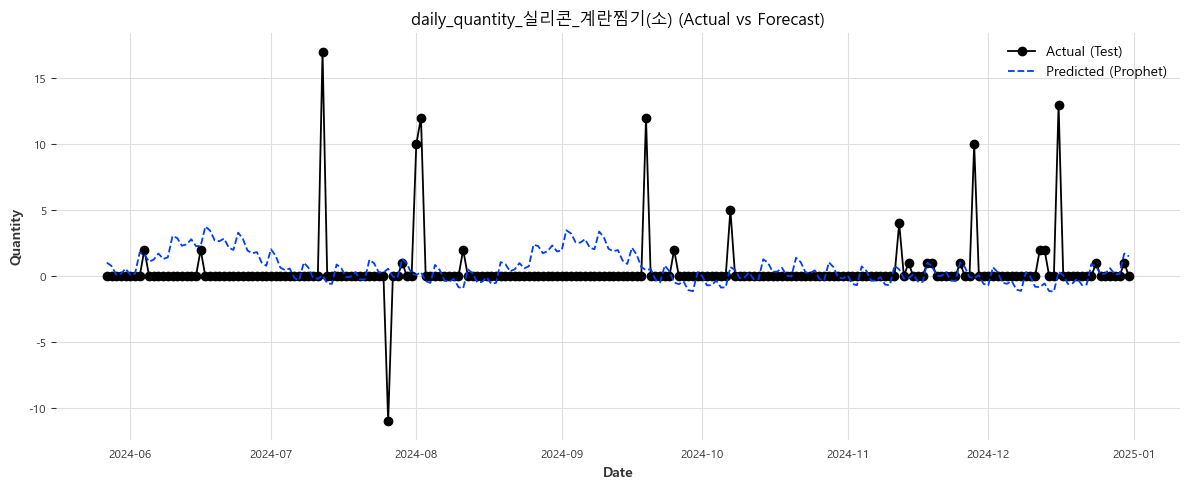

품목: daily_quantity_실리콘_뒤짐개


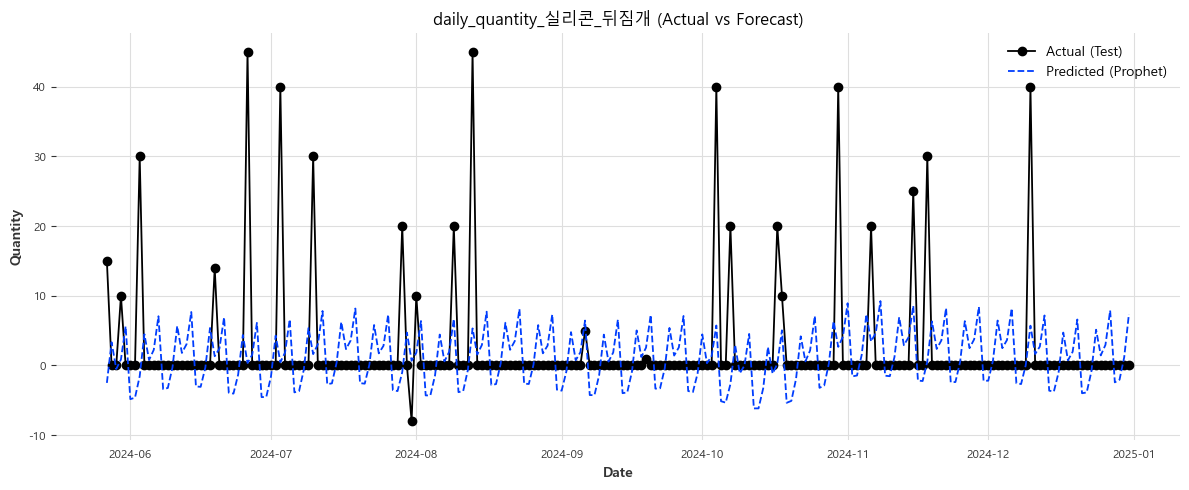

품목: daily_quantity_실리콘_볶음주걱


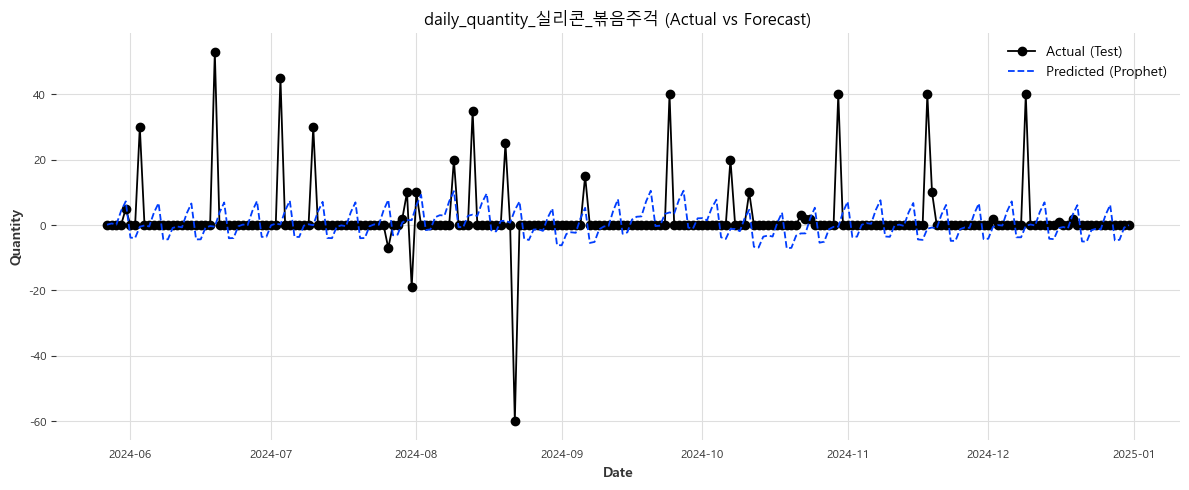

품목: daily_quantity_내열장갑


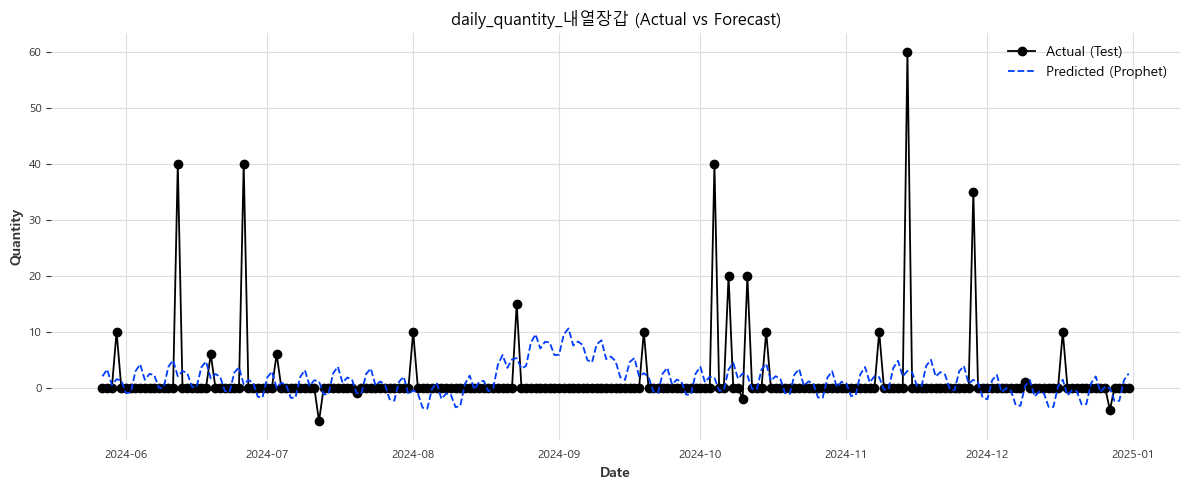

품목: daily_quantity_실리콘_계란찜기(대)


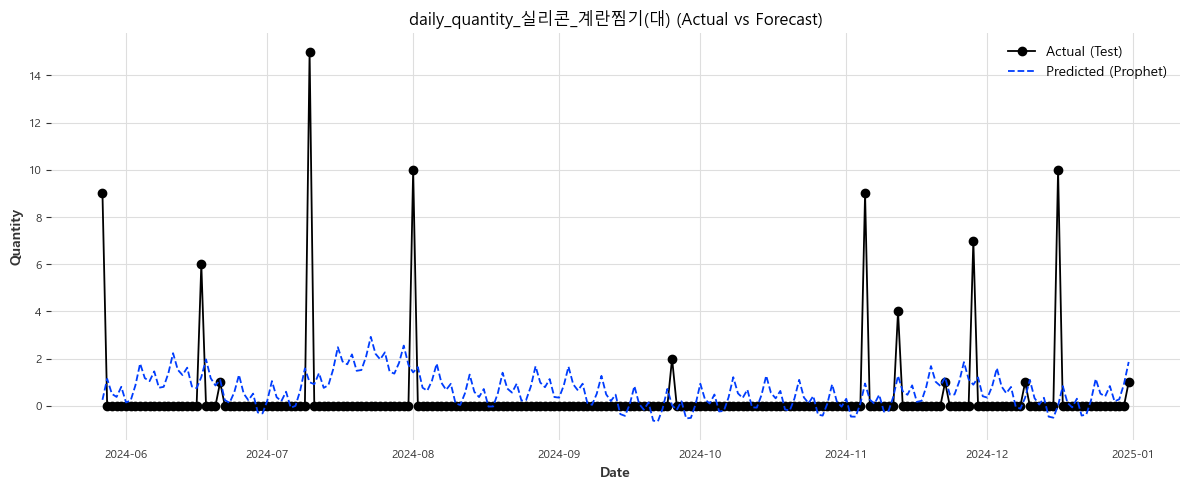

품목: daily_quantity_실리콘_도마(대)


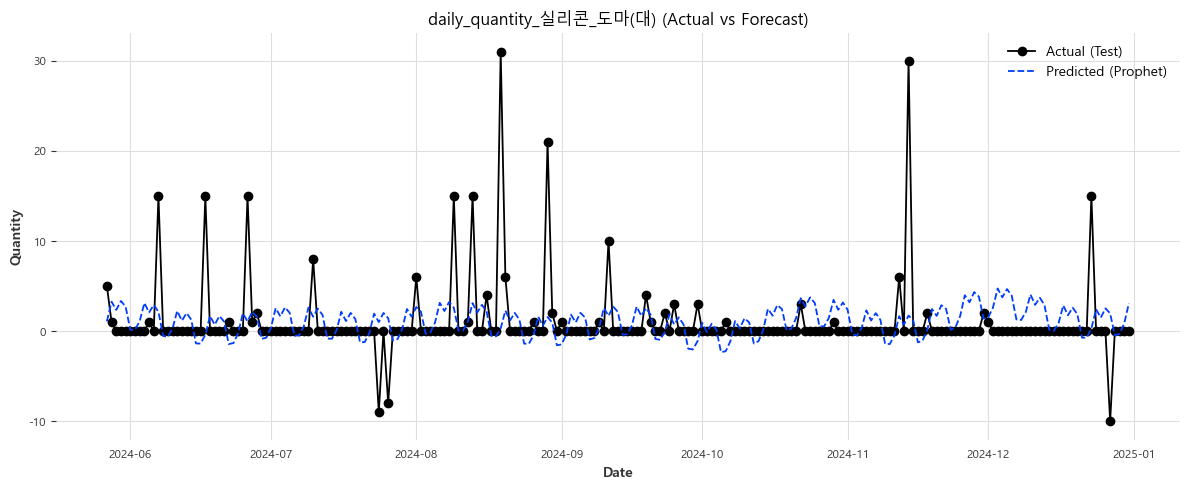

품목: daily_quantity_실리콘_냄비잡이


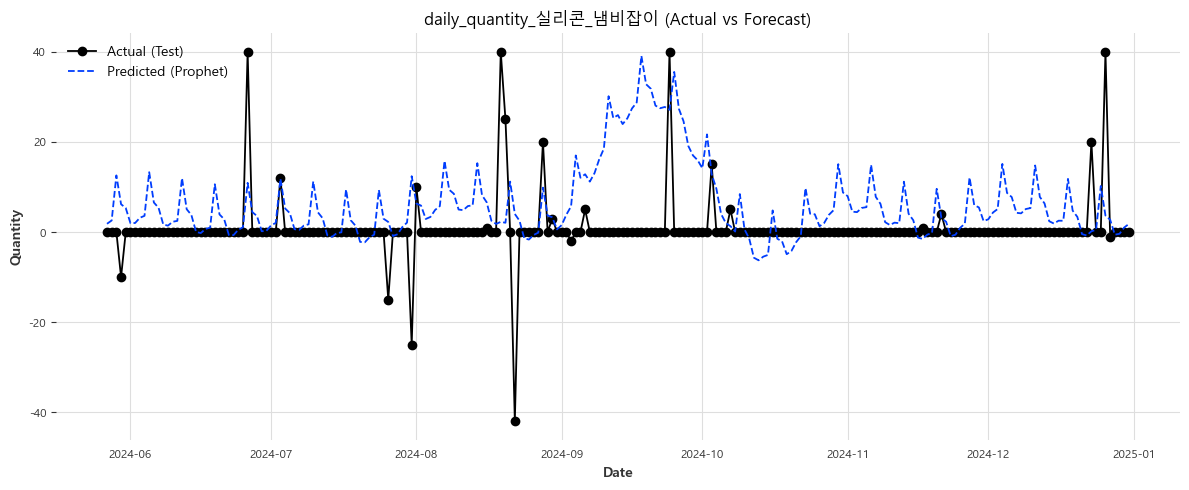

품목: daily_quantity_실리콘_스테인리스집게(소)


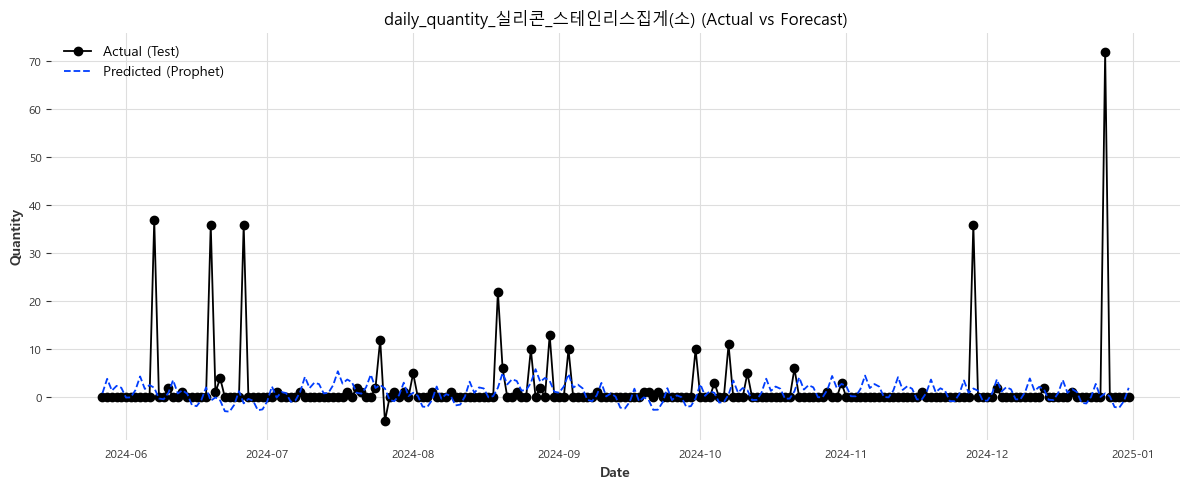

품목: daily_quantity_오픈수납함


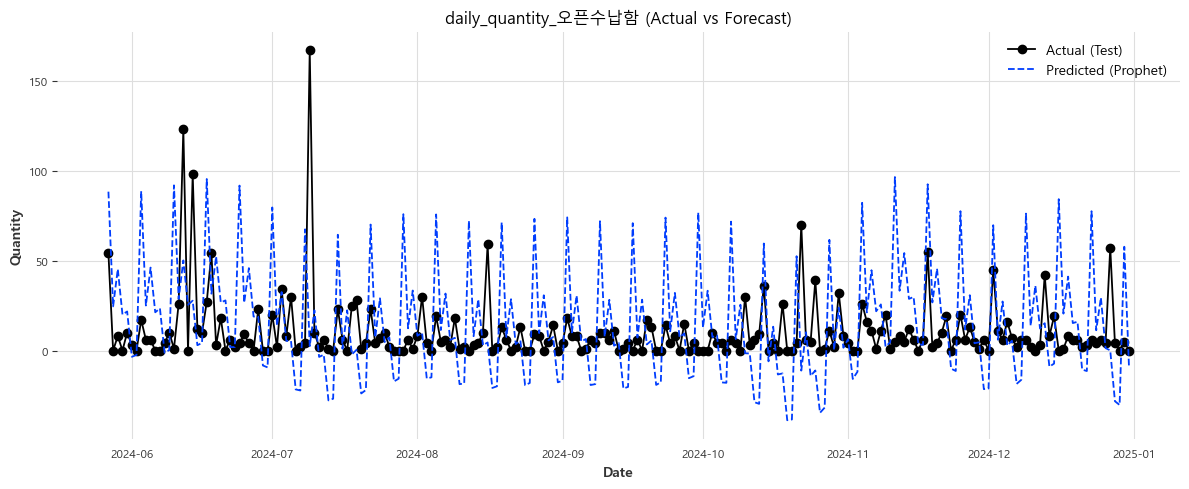

품목: daily_quantity_실리콘_계란찜기(중)


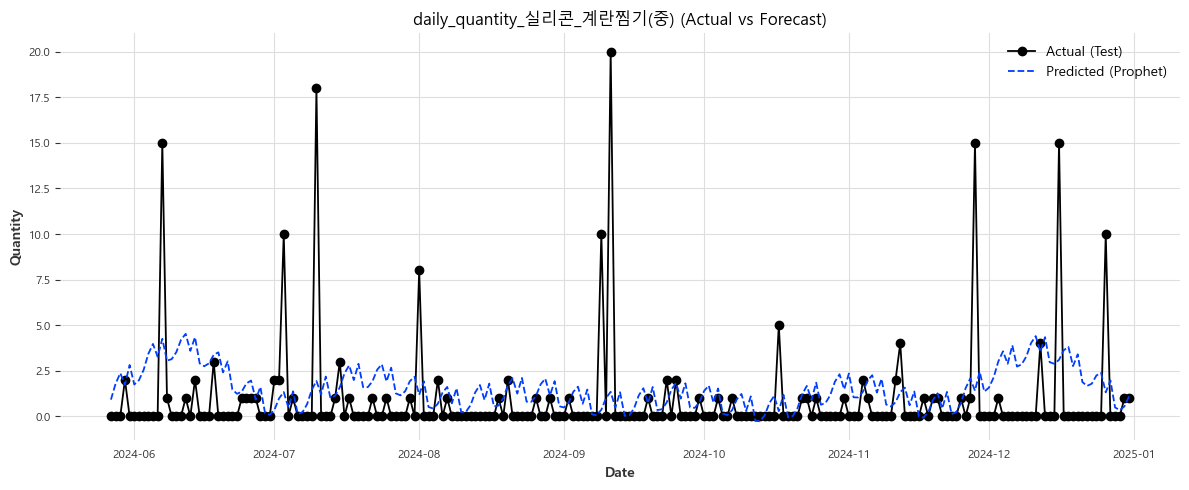

품목: daily_quantity_실리콘_도마(중)


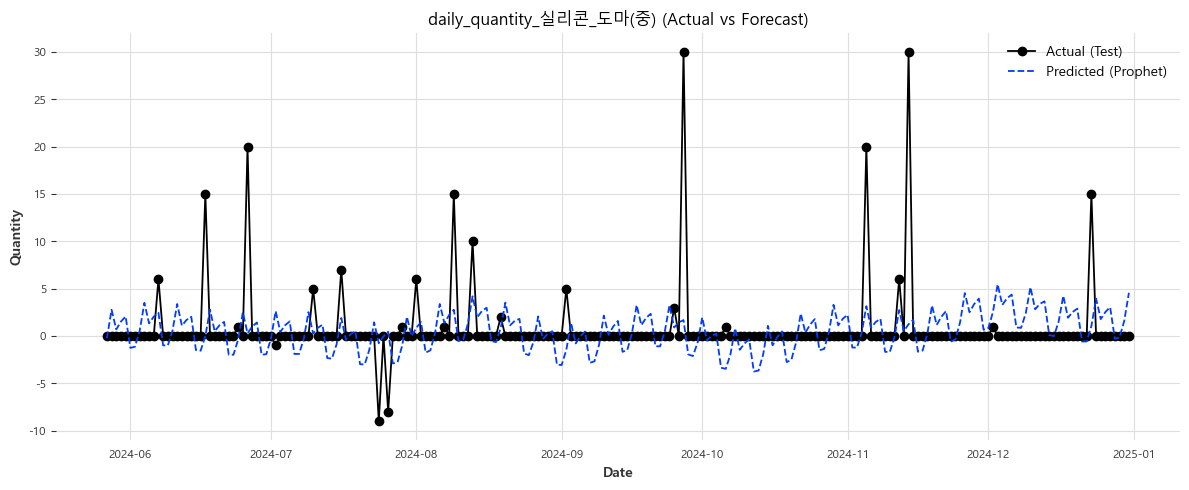

품목: daily_quantity_실리콘_멀티스푼


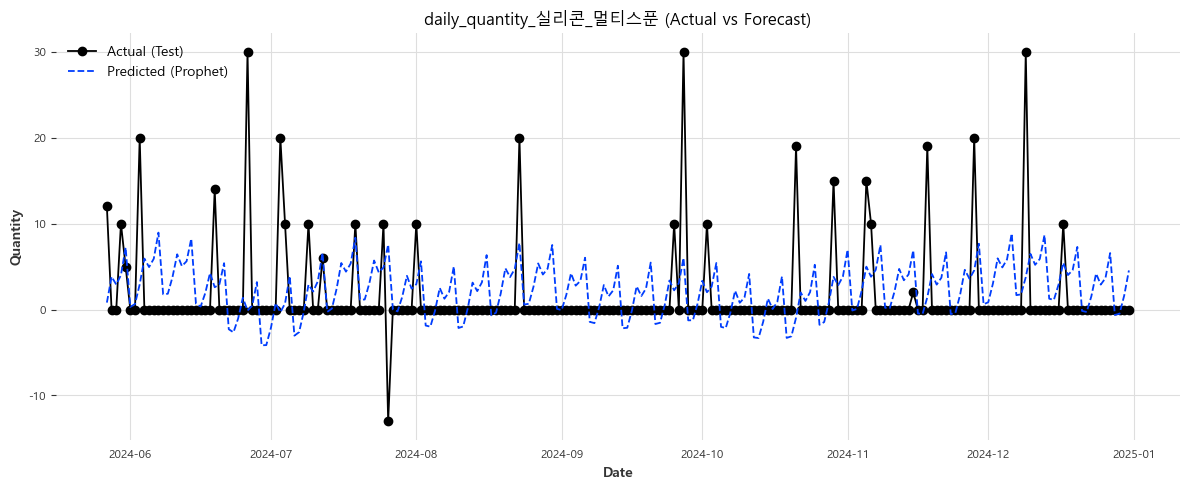

품목: daily_quantity_실리콘_비누받침


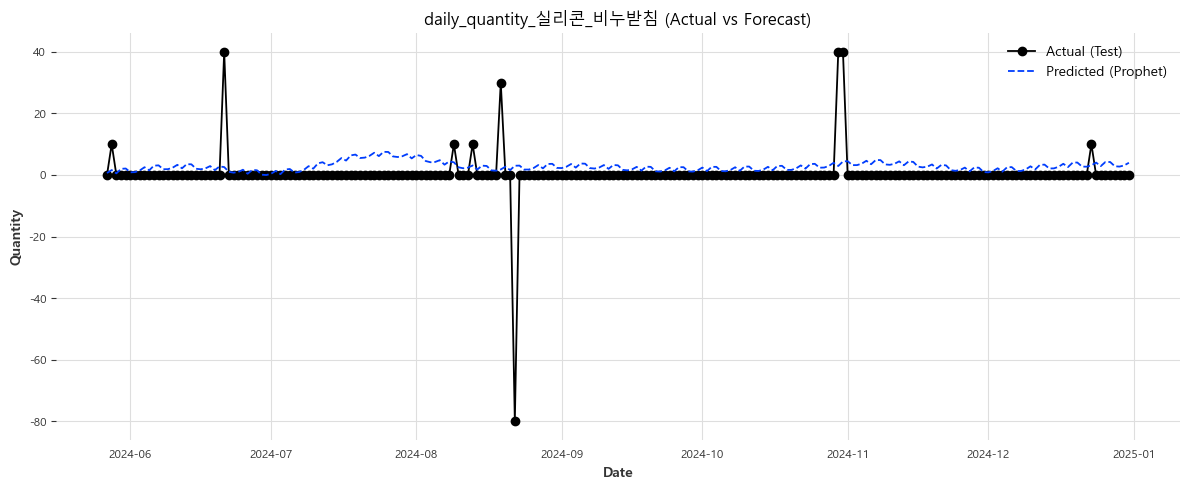

품목: daily_quantity_실리콘_스테인리스집게(대)


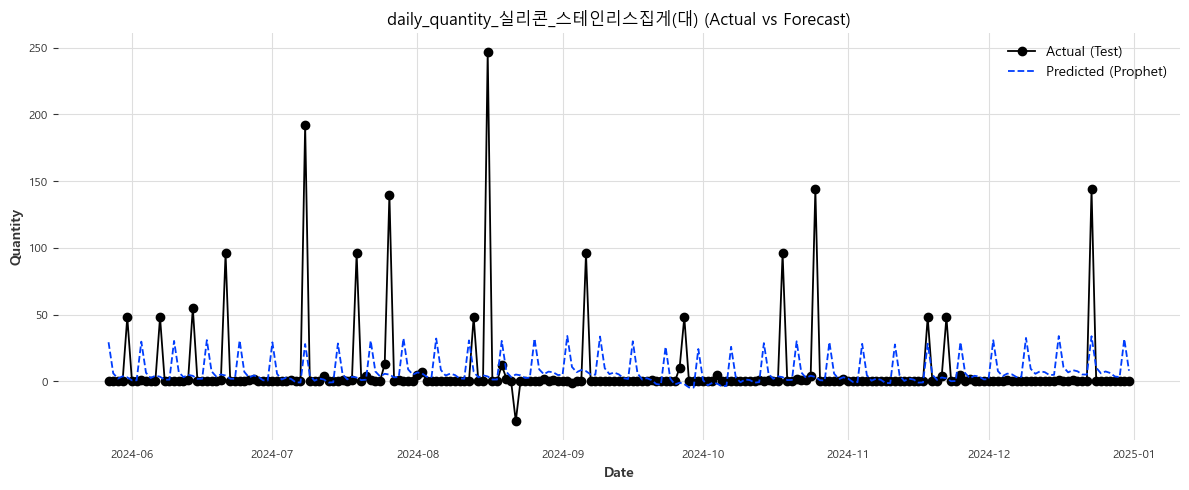

품목: daily_quantity_실리콘_다용도 오일브러쉬


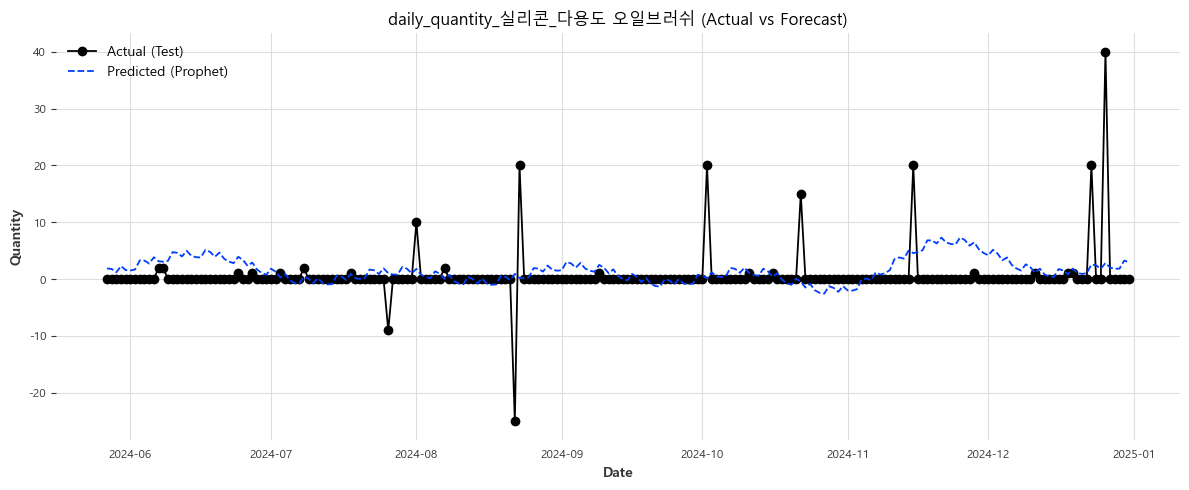

품목: daily_quantity_실리콘_덮개세트_샤크


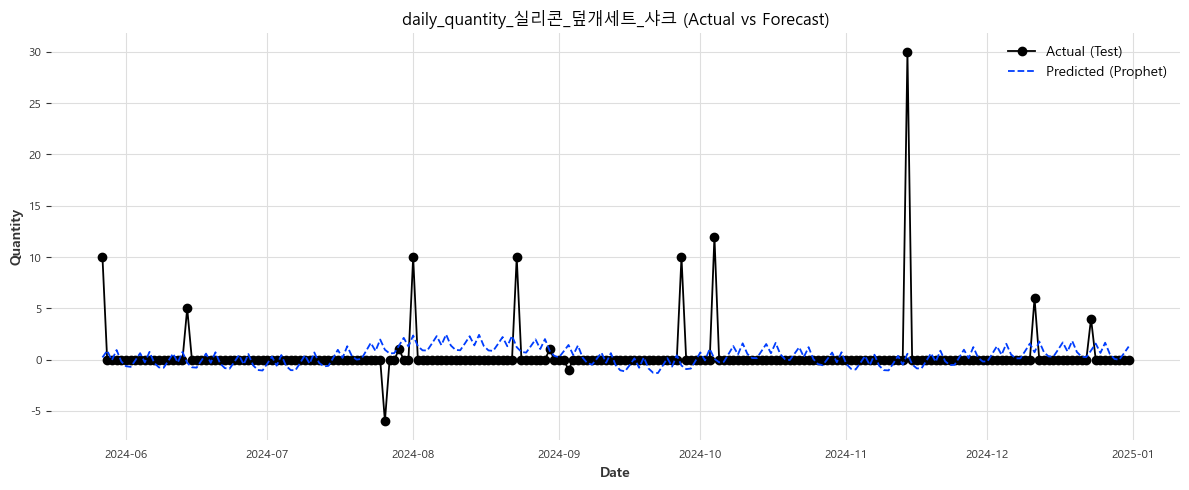

In [42]:
plot_all_forecasts1(test_df, all_forecasts, target_cols)

***

## 2. Croston (간헐적 수요 특화)
- 0이 자주 발생하는 수요 데이터를 예측하기 위한 통계 모델
- 단변량만 지원
- 간헐적 수요에 대해 단순하고 안정적인 수요 예측치를 제공
- 수요가 발생한 시점들만을 기반으로 수요 크기와 수요 간격을 따로 추정, 그리고 미래에는 이 추정값을 곱해서 고정된 예측치를 만든다.
    - 예측 = 수요 크기 평균 / 수요 간격 평균 → 일정한 값이 나옴.
- sba 버전 (Syntetos–Boylan Approximation): Croston보다 편향이 적음, 수요가 정기적으로 발생할 때 더 나은 성능
- tsb 버전 (Teunter–Syntetos–Babai): 0이 자주 나오는 완전한 간헐적 수요에 강함, 예측값이 점점 0에 가까워질 수 있어서 현실적

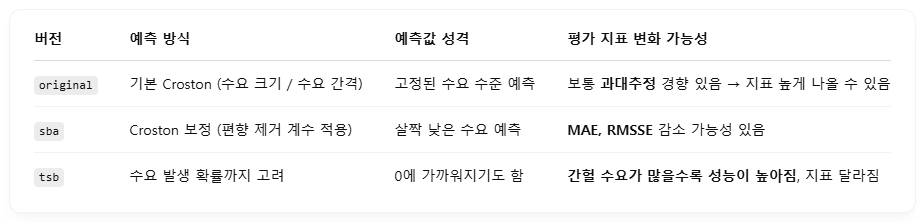

- 일반적인 예측 모델은 모든 시점의 값을 예측하지만, Croston은 수요 발생이 '있었던 시점'과 '간격'을 분리해서 예측
- 예측 대상: 수요 크기(수요가 발생한 시점의 크기만 따로 모음), 수요 간격(수요 발생 간의 간격-몇 시점마다 발생하는지를 따로 모음)
  - 이 두 시퀀스를 따로 지수평활법으로 예측: 최종 예측값 = 예측된 수요 크기 / 예측된 간격


In [15]:
def croston_forecast_evaluate(train_df, test_df, col):
    train_y = train_df[col].values
    test_y = test_df[col].values

    # Croston 예측 (미래에 예측할 기간: test set 길이만큼 / Croston의 기본 버전 사용)
    # train_y를 학습하고, test_y 길이만큼 미래 예측, 'original'은 Croston의 가장 기본 버전
    fit_pred = croston.fit_croston(train_y, len(test_y), 'original')  # 공식 문서 참고

    # test 기간에 해당하는 예측값들을 배열로 받음
    croston_forecast = fit_pred['croston_forecast']

    # 평가 지표 계산
    rmse = np.sqrt(mean_squared_error(test_y, croston_forecast))
    mae = mean_absolute_error(test_y, croston_forecast)

    # Naive 모델 (이전값 그대로)
    naive_forecast = train_df[col].shift(1).dropna().values
    naive_actual = train_df[col][1:].values

    mase_denom = np.mean(np.abs(naive_actual - naive_forecast))
    rmsse_denom = np.sqrt(np.mean((naive_actual - naive_forecast) ** 2))

    mase = mae / mase_denom if mase_denom != 0 else np.nan
    rmsse = rmse / rmsse_denom if rmsse_denom != 0 else np.nan

    # 결과를 DataFrame으로 저장
    forecast_df = test_df[['date']].copy()
    forecast_df[f'forecast_{col}'] = croston_forecast

    return forecast_df, rmsse, mase

fit_pred = croston.fit_croston(ts, 10, 'original') # croston's method
- input_endog – numpy array of intermittent demand time series
- forecast_length – forecast horizon
- croston_variant – croston model type

In [16]:
croston_forecasts = [] # 각 품목에 대한 예측 결과(DataFrame)를 리스트로 저장
croston_rmsse_results = {} # 품목별 RMSSE 점수를 저장하는 딕셔너리
croston_mase_results = {} # 품목별 MASE 점수를 저장하는 딕셔너리

for col in tqdm(target_cols):
    forecast, rmsse, mase = croston_forecast_evaluate(train_df, test_df, col)
    croston_forecasts.append(forecast)
    croston_rmsse_results[col] = rmsse
    croston_mase_results[col] = mase

100%|██████████████████████████████████████████████████████████████████████████████████████| 16/16 [00:01<00:00, 14.80it/s]


In [60]:
croston_forecasts

[           date  forecast_daily_quantity_실리콘_계란찜기(소)
 875  2024-05-27                             0.805715
 876  2024-05-28                             0.805715
 877  2024-05-29                             0.805715
 878  2024-05-30                             0.805715
 879  2024-05-31                             0.805715
 ...         ...                                  ...
 1089 2024-12-27                             0.805715
 1090 2024-12-28                             0.805715
 1091 2024-12-29                             0.805715
 1092 2024-12-30                             0.805715
 1093 2024-12-31                             0.805715
 
 [219 rows x 2 columns],
            date  forecast_daily_quantity_실리콘_뒤짐개
 875  2024-05-27                         4.156289
 876  2024-05-28                         4.156289
 877  2024-05-29                         4.156289
 878  2024-05-30                         4.156289
 879  2024-05-31                         4.156289
 ...         ...         

In [17]:
# 각 지표에 대해 전체 평균값을 계산
avg_croston_rmsse = sum(croston_rmsse_results.values()) / len(croston_rmsse_results)
avg_croston_mase = sum(croston_mase_results.values()) / len(croston_mase_results)

# 전체적인 성능 출력
print("=== 전체 Croston_original 모델링 성능 ===")
print(f"전체 RMSSE 평균: {avg_croston_rmsse:.2f}")
print(f"전체 MASE 평균: {avg_croston_mase:.2f}")

=== 전체 Croston_original 모델링 성능 ===
전체 RMSSE 평균: 0.47
전체 MASE 평균: 0.81


tsb 버전을 사용해보자!

전체적인 성능이 기본 버전과 유사하게 나온다,,

## 예측 시각화

In [18]:
def plot_forecast_result2(test_df, forecast_df, col):
    # 'date'를 기준으로 병합
    plot_df = pd.merge(test_df[['date', col]], forecast_df, how='left', on='date')

    plt.figure(figsize=(12, 5))
    plt.plot(plot_df['date'], plot_df[col], label='Actual (Test)', marker='o')
    plt.plot(plot_df['date'], plot_df[f'forecast_{col}'], label='Predicted (Croston)', linestyle='--')
    
    plt.title(f'{col} (Actual vs Forecast - Croston)')
    plt.xlabel('Date')
    plt.ylabel('Quantity')
    
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [19]:
def plot_all_forecasts2(test_df, all_forecasts, target_cols):
    for col, forecast_df in zip(target_cols, all_forecasts):
        print(f"품목: {col}")
        plot_forecast_result2(test_df, forecast_df, col)

품목: daily_quantity_실리콘_계란찜기(소)


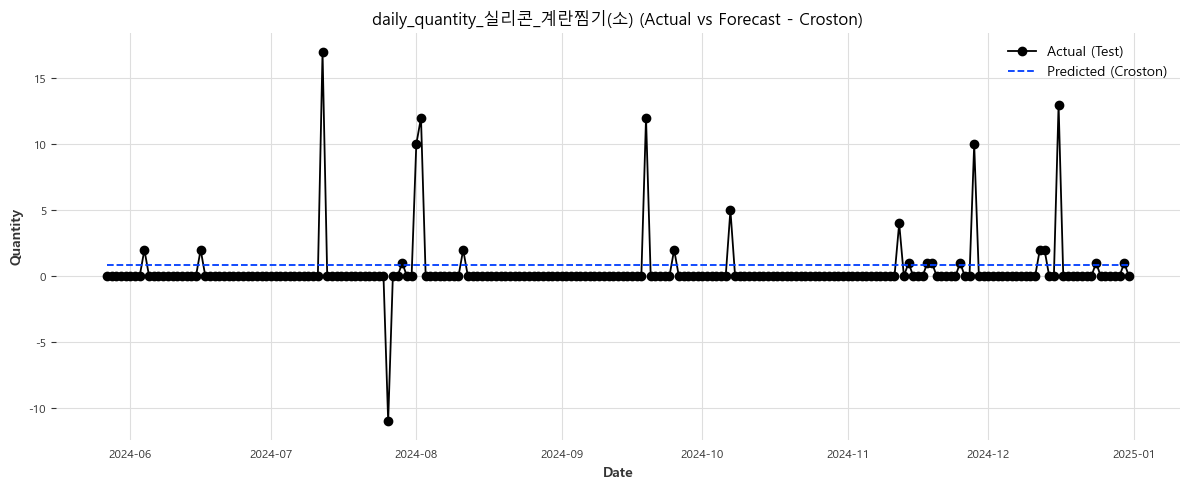

품목: daily_quantity_실리콘_뒤짐개


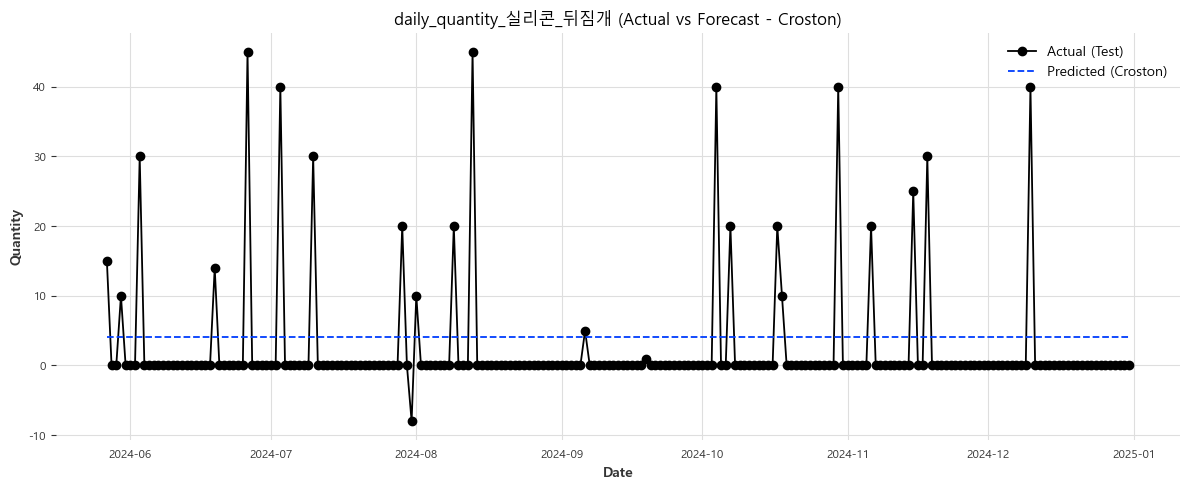

품목: daily_quantity_실리콘_볶음주걱


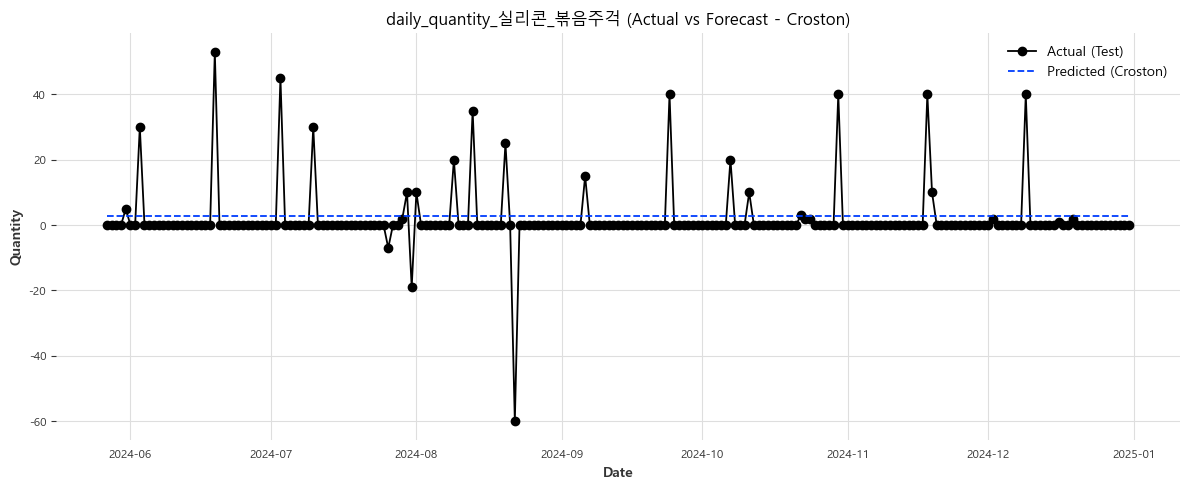

품목: daily_quantity_내열장갑


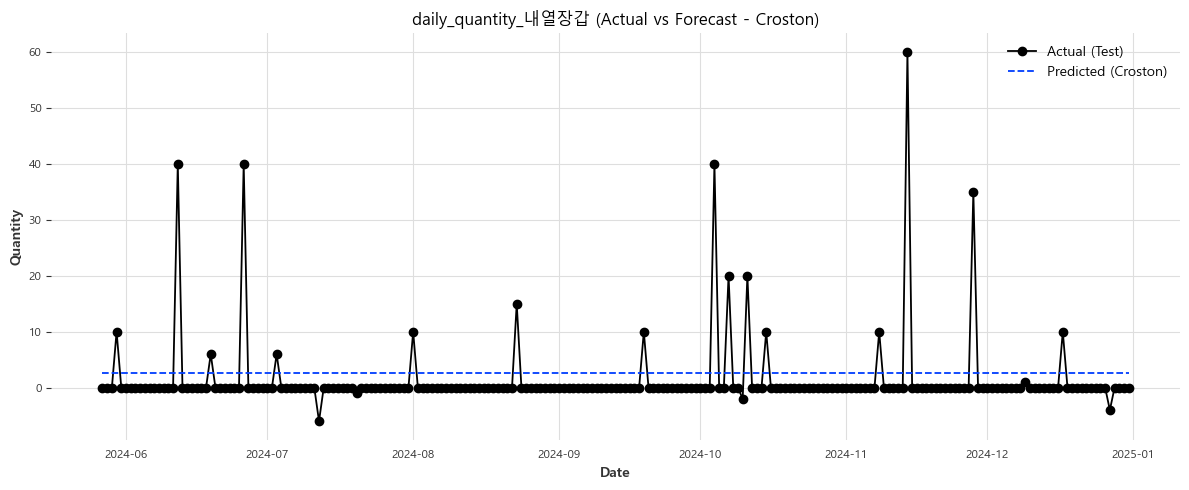

품목: daily_quantity_실리콘_계란찜기(대)


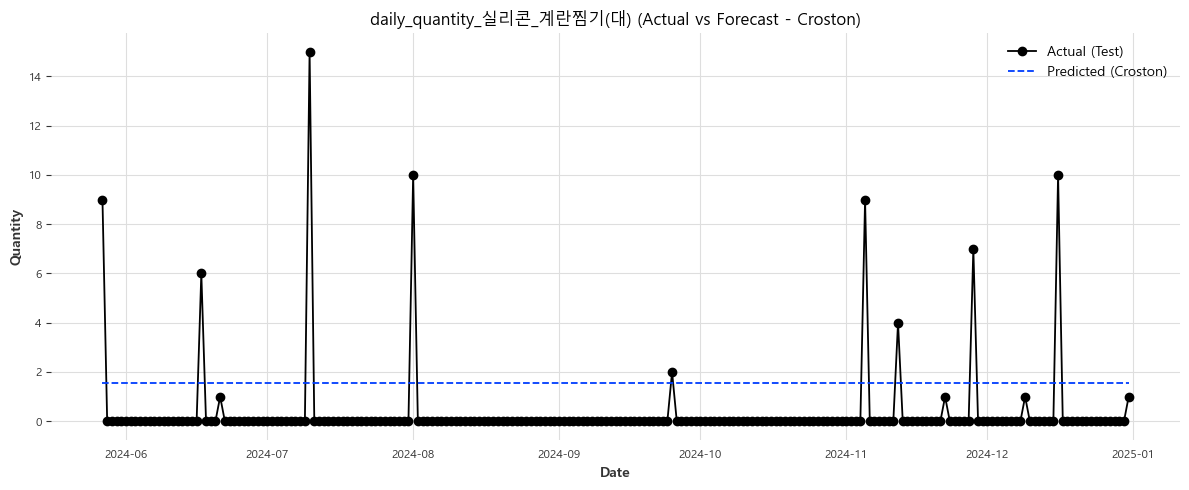

품목: daily_quantity_실리콘_도마(대)


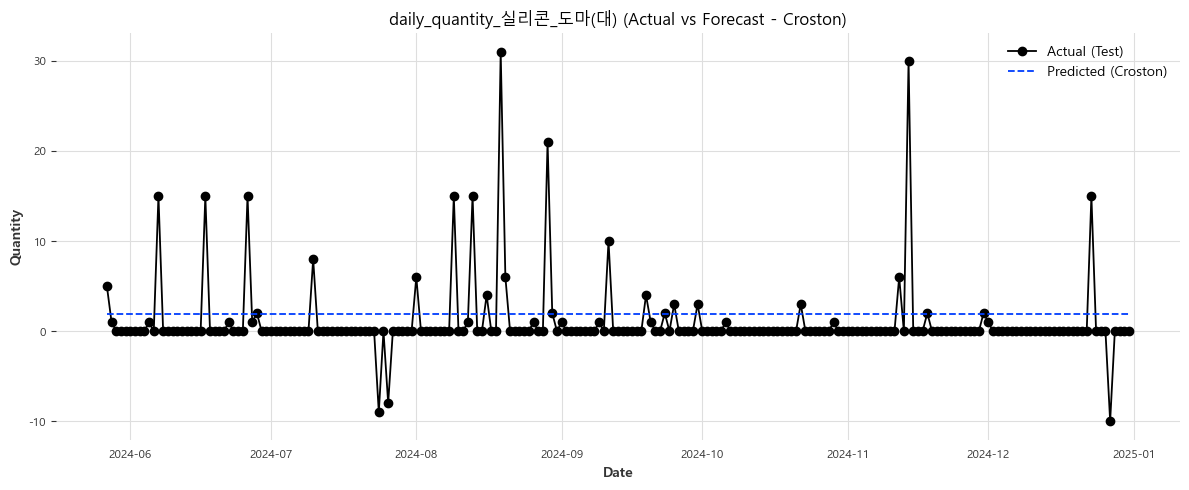

품목: daily_quantity_실리콘_냄비잡이


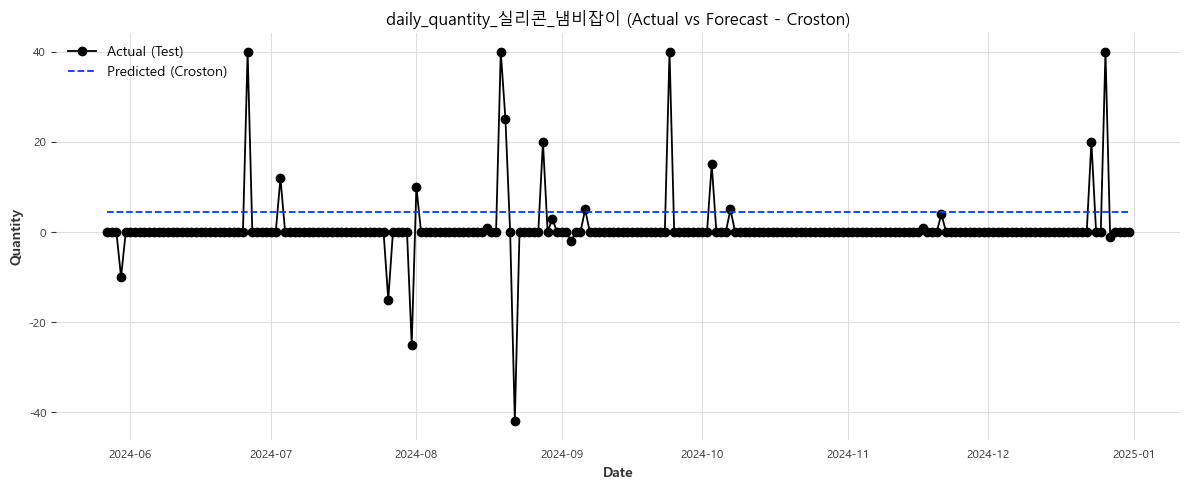

품목: daily_quantity_실리콘_스테인리스집게(소)


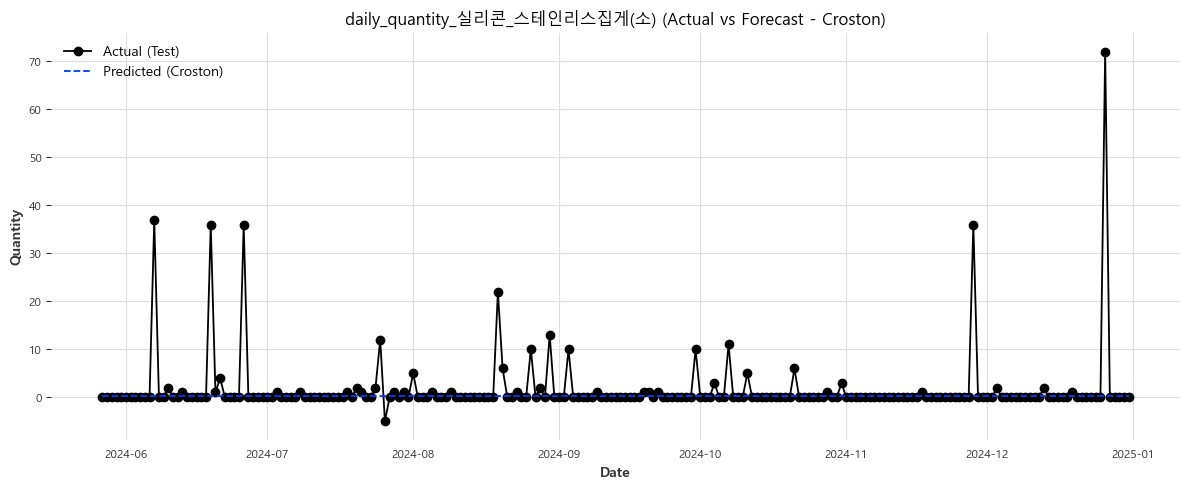

품목: daily_quantity_오픈수납함


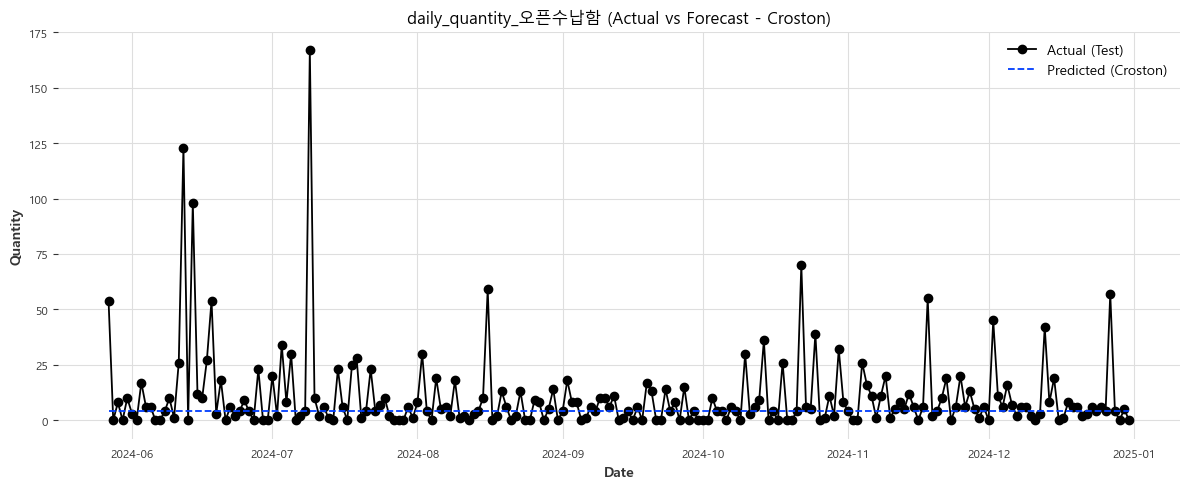

품목: daily_quantity_실리콘_계란찜기(중)


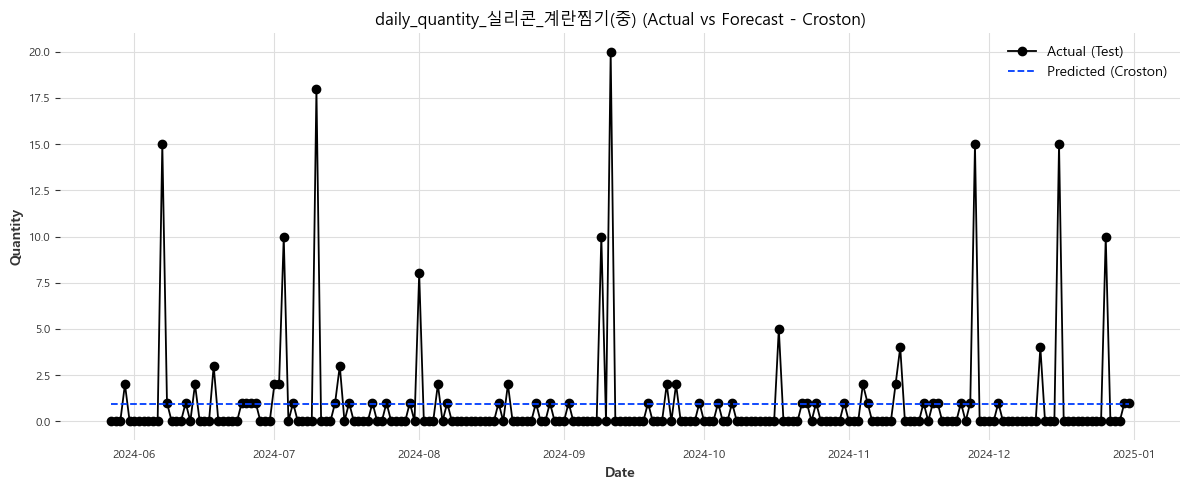

품목: daily_quantity_실리콘_도마(중)


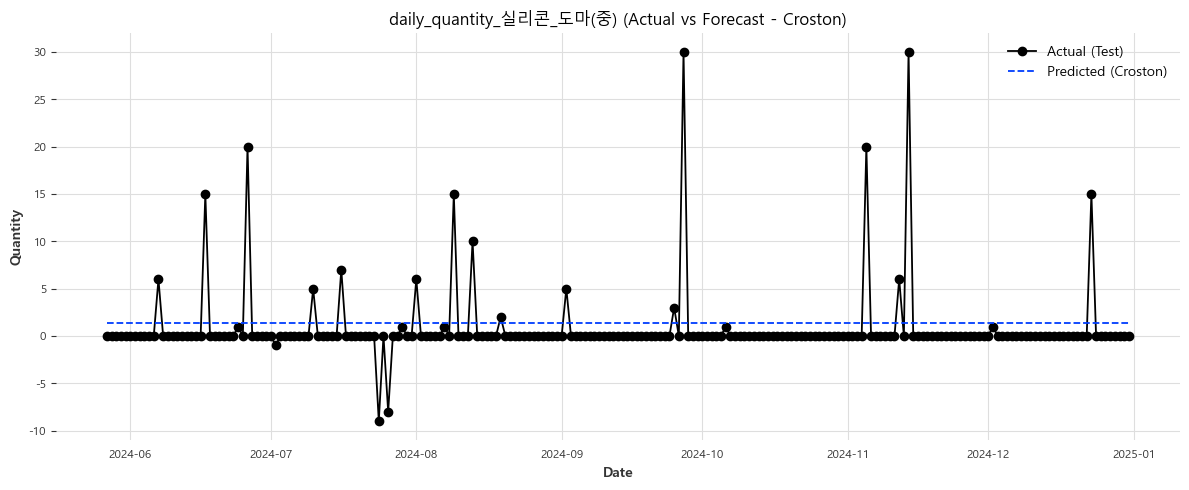

품목: daily_quantity_실리콘_멀티스푼


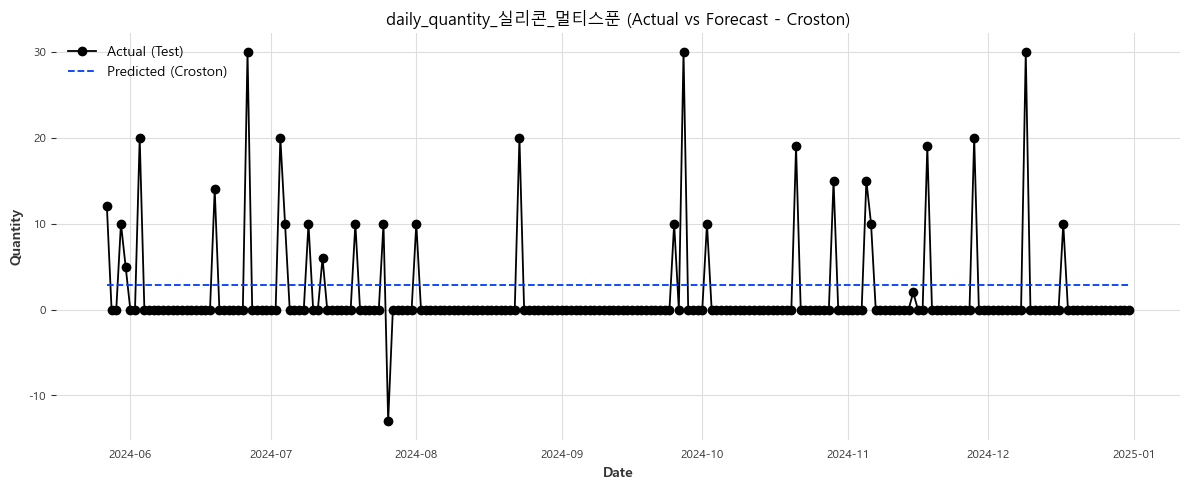

품목: daily_quantity_실리콘_비누받침


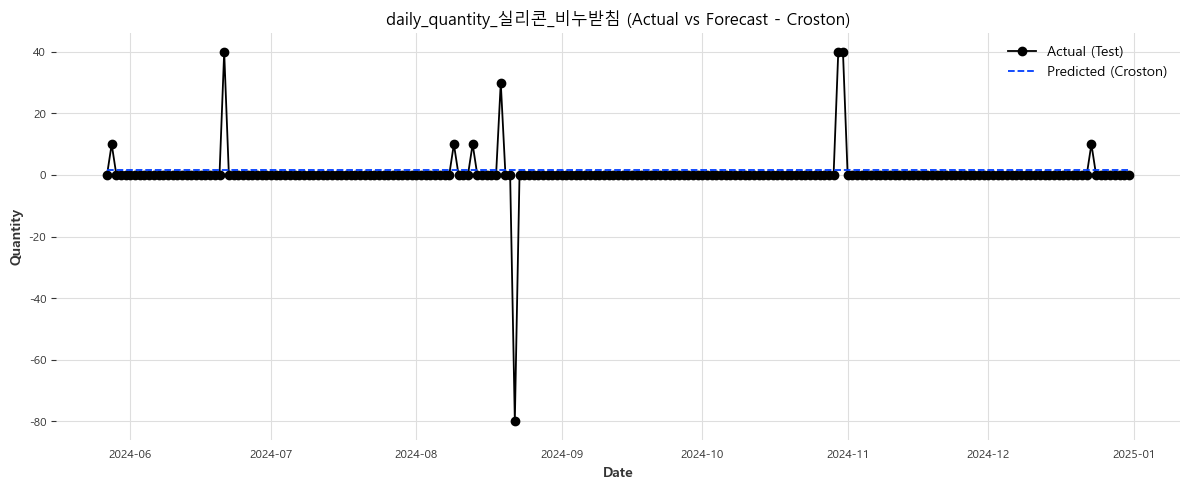

품목: daily_quantity_실리콘_스테인리스집게(대)


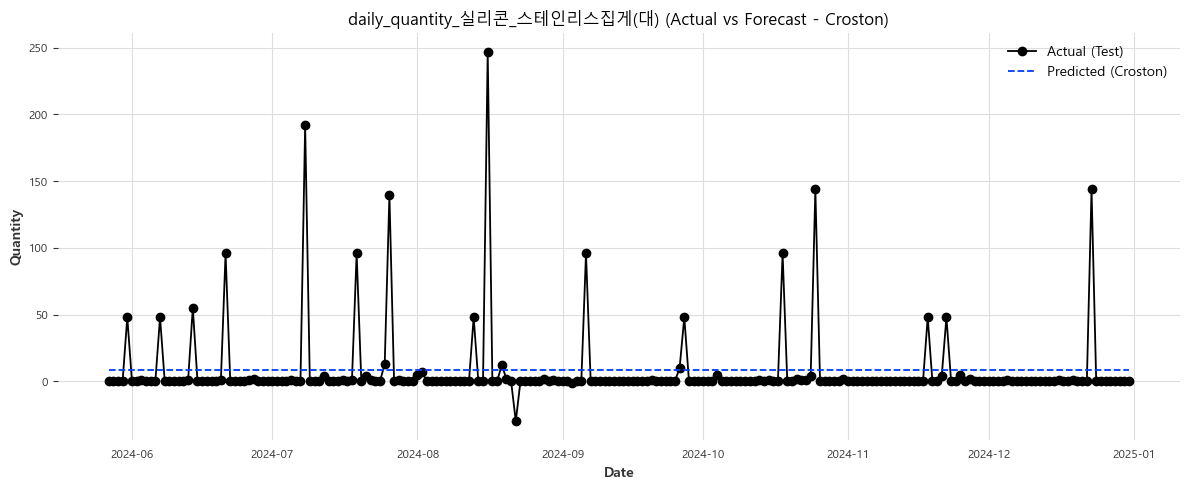

품목: daily_quantity_실리콘_다용도 오일브러쉬


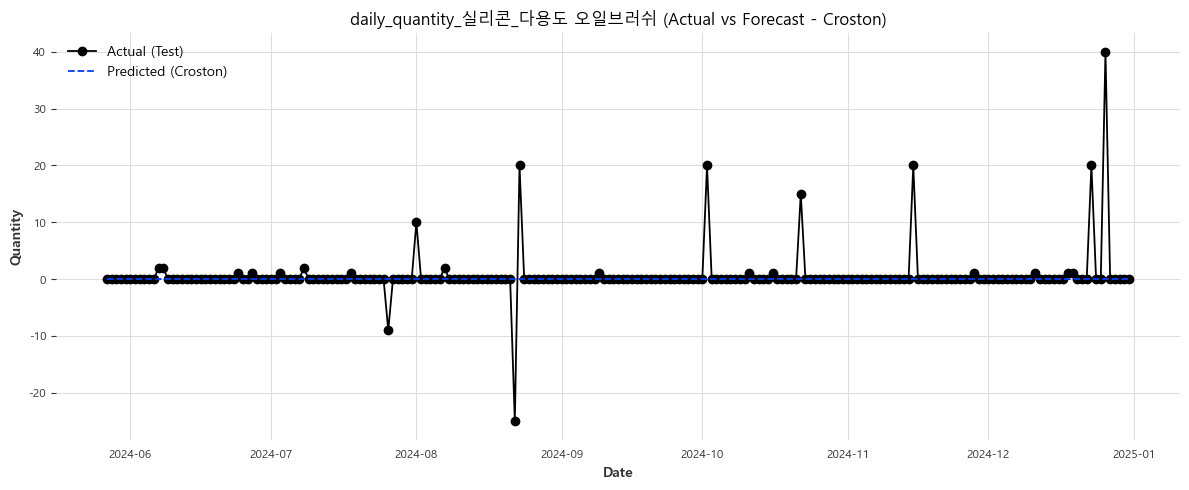

품목: daily_quantity_실리콘_덮개세트_샤크


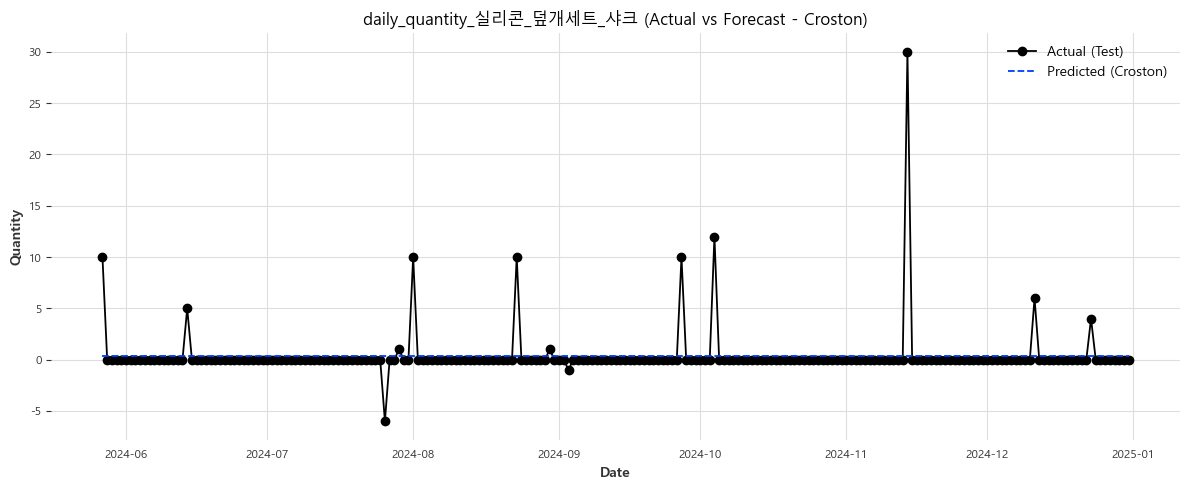

In [43]:
plot_all_forecasts2(test_df, croston_forecasts, target_cols)

***

## 3. VARIMA (다변량 시계열: 변수 간 상관성 반영)
: 여러 시계열 간의 상호 관계를 고려하면서, 비정상성을 제거하고, 과거 오차까지 활용해서 예측하는 모델
- 시계열 데이터 중 다변량 시계열(multivariate time series)에 사용하는 예측 모델
- 여러 시계열 변수들의 과거 값과 과거 오차를 함께 고려해서 예측하는 모델
- ARIMA 확장: 여러 시계열의 상호 영향을 반영하여 예측

> VARIMA = VAR + I + MA

> VAR (Vector AutoRegression)
: 여러 시계열 변수들 간의 상호 관계를 반영하여 예측.
→ 예: A 상품 수요가 B 상품 수요에 영향을 줄 때

> I (Integrated)
: 비정상(non-stationary) 데이터를 차분(differencing)하여 정상화.
→ 시간에 따라 평균/분산이 변하는 데이터를 안정화시킴

> MA (Moving Average)
: 과거 오차 항의 영향도 고려함.

In [21]:
# 시계열 객체로 변환 (date를 인덱스로 설정)
series = TimeSeries.from_dataframe(full_data, time_col='date')

In [22]:
series

<TimeSeries (DataArray) (date: 1094, component: 16, sample: 1)> Size: 140kB
array([[[ 0.],
        [ 0.],
        [ 0.],
        ...,
        [40.],
        [ 0.],
        [ 0.]],

       [[ 0.],
        [ 0.],
        [ 0.],
        ...,
        [ 1.],
        [ 0.],
        [ 0.]],

       [[ 0.],
        [30.],
        [ 0.],
        ...,
...
        ...,
        [ 0.],
        [ 0.],
        [ 0.]],

       [[ 1.],
        [ 0.],
        [ 0.],
        ...,
        [ 0.],
        [ 0.],
        [ 0.]],

       [[ 0.],
        [ 0.],
        [ 0.],
        ...,
        [ 0.],
        [ 0.],
        [ 0.]]])
Coordinates:
  * date       (date) datetime64[ns] 9kB 2022-01-03 2022-01-04 ... 2024-12-31
  * component  (component) <U29 2kB 'daily_quantity_실리콘_계란찜기(소)' ... 'daily_q...
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None
    metadata:           None

In [23]:
train, test = series[:875], series[875:]

- Darts에서는 TimeSeries 객체로 데이터를 사용해야 하니까, full_data에서 date를 시계열 인덱스로 설정한 후 TimeSeries로 변환
- order=(p, d, q)는 AR, 차분, MA의 차수
> 예시: order=(2, 1, 1)
>- p=2: 2 시점 전까지 과거 관측값 사용
>- d=1: 1번 차분 → 추세 제거
>- q=1: 1 시점 전까지의 예측 오차 사용

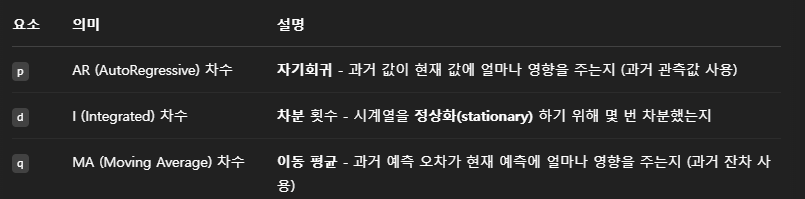

전체 컬럼에 대해서 모델링 -> 시간 오래 소요,,

## VARIMA 성능 출력

모든 컬럼을 순회하며 varima 모델링

16개 컬럼을 동시에 학습하려고 하면 내부적으로 공분산 행렬 추정, 최적화 반복, 모수 추정이 한꺼번에 되기 때문에 시간이 오래 걸림,,

> 어떻게 해결해야 할까?
> 1. 컬럼 수 줄이기 (중요한 상품만 먼저 선택)
> 2. 데이터 양 줄이기 (예: 최근 6개월만 사용)
> 3. 모델 설정 간단히 하기 (order 튜닝X, 디폴트 사용)
> 4. 개별 예측으로 전환 (VARIMA 대신 각 컬럼별로 Prophet, RF 등)

### 우선, 최근 1년 데이터 사용해 VARIMA + 정규화
- 변수 간 단위나 스케일 차이가 큰 경우/전체 변수의 패턴을 균형 있게 학습시키고 싶을 때 -> 정규화
- 모든 변수들이 비슷한 크기의 값을 갖고 있다면 굳이 정규화 안 해도 됨!

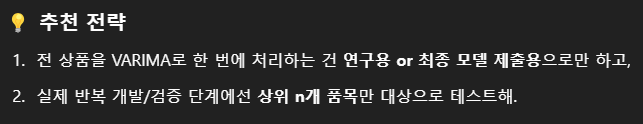

- VARIMA는 공분산 행렬 계산이 들어가기 때문에, 컬럼 간 분산 차이가 크면 불안정해질 수 있다.
- 따라서 각 컬럼을 min-max 정규화하거나 표준화하면 안정적이고 빨라질 수 있다.

## 최근 2년 데이터 VARIMA + 정규화

## 전체 데이터 시도해보기 + 정규화

In [30]:
df = full_data.copy()

# 컬럼 정규화
target_cols = df.columns.drop('date')
scaler = StandardScaler()
scaled = scaler.fit_transform(df[target_cols])
scaled_df = pd.DataFrame(scaled, columns=target_cols)
scaled_df['date'] = df['date'].values

# TimeSeries 객체로 변환
series = TimeSeries.from_dataframe(scaled_df, time_col='date')

# 데이터 분할
train_size = int(len(series) * 0.8)
train_series = series[:train_size]
test_series = series[train_size:]

In [31]:
model = VARIMA(1, 0, 0) # 기본 설정
model.fit(train_series)
forecast = model.predict(len(test_series))

In [32]:
# 정규화된 예측과 실제값 복원
y_pred_scaled = forecast.values()
y_true_scaled = test_series.values()
y_train_scaled = train_series.values()

# 스케일 복원
y_pred = scaler.inverse_transform(
    np.concatenate([y_train_scaled, y_pred_scaled])[-len(y_pred_scaled):]
)
y_true = scaler.inverse_transform(
    np.concatenate([y_train_scaled, y_true_scaled])[-len(y_true_scaled):]
)
y_train = scaler.inverse_transform(y_train_scaled)

# naive 예측 (1-step 시차 naive)
naive_forecast = y_train[:-1]
naive_actual = y_train[1:]

# MASE, RMSSE 계산
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

mase_denom = np.mean(np.abs(naive_actual - naive_forecast))
rmsse_denom = np.sqrt(np.mean((naive_actual - naive_forecast) ** 2))

mase = mae / mase_denom if mase_denom != 0 else np.nan
rmsse = rmse / rmsse_denom if rmsse_denom != 0 else np.nan

# 결과 출력
print("=== VARIMA 모델 성능 (전체 상품 컬럼 기준) ===")
print(f"MASE  : {mase:.2f}")
print(f"RMSSE : {rmsse:.2f}")

=== VARIMA 모델 성능 (전체 상품 컬럼 기준) ===
MASE  : 0.61
RMSSE : 0.27


In [61]:
y_pred

array([[0.68398712, 4.1013502 , 3.73867985, ..., 7.68346374, 0.6136821 ,
        0.46131505],
       [0.67676469, 4.30817474, 3.84130336, ..., 6.35936459, 0.67441577,
        0.61558603],
       [0.65857604, 4.27401439, 3.85232043, ..., 6.33231568, 0.66140828,
        0.61595941],
       ...,
       [0.65904936, 4.27422303, 3.85648995, ..., 6.34003656, 0.65813528,
        0.61608775],
       [0.65904936, 4.27422303, 3.85648995, ..., 6.34003656, 0.65813528,
        0.61608775],
       [0.65904936, 4.27422303, 3.85648995, ..., 6.34003656, 0.65813528,
        0.61608775]])

## Actual vs Predict 시각화

In [50]:
def plot_varima_forecast(test_df, y_pred, y_true, col, target_cols):
    plot_df = pd.merge(test_df[['date', col]], forecast_df, how='left', left_on='date', right_on='ds')
    
    # 시각화
    plt.figure(figsize=(12, 5))
    plt.plot(actual_df['date'], plot_df[col], label='Actual (Test)', marker='o')
    plt.plot(forecast_df['date'], plot_df[f'forecast_{col}'], label='Predicted (VARIMA)', linestyle='--')
    
    plt.title(f'{col} (Actual vs Forecast - VARIMA)')
    plt.xlabel('Date')
    plt.ylabel('Quantity')
    
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [52]:
def plot_all_varima_forecasts(test_df, y_pred, y_true, target_cols):
    for col, forecast_df in zip(target_cols, all_forecasts):
        # 컬럼명에 맞게 예측 결과 컬럼명 변경
        # Prophet은 예측값을 항상 'yhat'이라는 컬럼에 저장 -> 컬럼명을 "forecast_품목"명으로 변경
        forecast_df = forecast_df.rename(columns={'yhat': f'forecast_{col}'}) if 'yhat' in forecast_df.columns else forecast_df
        
        print(f"품목: {col}")
        plot_varima_forecast(test_df, forecast_df, col)

In [53]:
# 시각화 실행
plot_all_varima_forecasts(test_df, y_pred, y_true, target_cols)

품목: daily_quantity_실리콘_계란찜기(소)


TypeError: plot_varima_forecast() missing 2 required positional arguments: 'col' and 'target_cols'

## 전체 데이터 VARIMA + 정규화X -> 오래 걸림
- VARIMA는 각 시계열 변수 간의 관계를 모델링하는 다변량 모델이기 때문에
  - 스케일 차이가 큰 변수들이 있을 경우 한 변수의 영향력이 과도하게 커질 수 있음
- 예를 들어, 어떤 상품을 하루 판매량이 100개씩, 어떤 상품은 하루에 1~2개만 팔린다면 -> 스케일 큰 변수에 모델이 더 집중
  - 변수 간 단위나 스케일 차이 큰 경우/전체 변수의 패턴을 균형 있게 학습시키길 원한다면 "정규화"

***

- 그런데 darts로 varima 실행하려니 너무 오래 걸림,, statsmodels의 varmax는?

***

## 4. 트리 기반 앙상블 모델 (Random Forest, XGBoost, LightGBM, CatBoost)
- 시계열 예측보다는 회귀 문제로 다룰 때 더 효과적
- 최근 날짜를 기준으로 Feature/Target을 구성해야 함
- 다변량 또는 단변량 구성 가능

> Random Forest, XGBoost, LightGBM, CatBoost와 같은 모델은 기계 학습 기반 모델로, 데이터를 피처로 변환하여 예측을 한다. 따라서 lag 피처를 사용하여 이전 값들을 입력으로 제공하면, 모델이 시간에 따른 패턴을 학습할 수 있게 된다.
> - Lag 피처: lag 피처는 주어진 시점에서 이전 값들을 예측하기 위한 특성으로 사용된다. 예를 들어, lag(1)은 바로 직전 시점의 값을 나타내며, lag(2)는 두 시점 전의 값을 나타낸다.
> - 트리 모델의 특성: 트리 기반 모델은 비선형 관계를 잘 학습할 수 있기 때문에, 과거 값(lag)을 기반으로 예측하는 것이 유효할 수 있다.

우선, 하나의 컬럼에 대해서만 랜덤 포레스트 수행해보기

In [36]:
def create_lag_features(df, col, lags):
    df = df.copy()
    for lag in lags:
        df[f'{col}_lag{lag}'] = df[col].shift(lag)
    return df

> GPT 추천 lag 세트: lags = [1, 2, 3, 7, 14, 30, 60, 90, 180, 365]
> - 1, 2, 3: 직전 며칠간의 흐름 파악
> - 7, 14: 주간 패턴 포착
> - 30, 60: 월간 트렌드
> - 90, 180, 365: 계절성과 장기 흐름

- random_state : 임의의 정수로 설정시 실행시마다 결과가 바뀌지 않고 고정됨

전체 컬럼에 대해서 랜덤 포레스트

In [37]:
# 결과 저장용 딕셔너리
rf_rmsse_results = {}
rf_mase_results = {}

target_cols = full_data.columns.drop('date').tolist()  # 예측 대상 품목 리스트
lags = [1, 2, 3, 7, 14, 30, 60, 90, 180, 365]

for col in target_cols:
    # 1. lag 생성
    df = create_lag_features(full_data.copy(), col, lags)
    df.dropna(inplace=True)

    # 2. train/test split
    split_index = int(len(df) * 0.8)
    train = df.iloc[:split_index]
    test = df.iloc[split_index:]

    X_train = train[[f'{col}_lag{lag}' for lag in lags]]
    y_train = train[col]
    X_test = test[[f'{col}_lag{lag}' for lag in lags]]
    y_test = test[col]

    # 3. 모델 학습 & 예측
    model = RandomForestRegressor(random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

     # 4. Naive 기반 성능 평가 직접 계산
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))

    # Naive 예측: 이전 시점 값
    naive_forecast = train[col].shift(1).dropna().values
    naive_actual = train[col][1:].values

    mase_denom = np.mean(np.abs(naive_actual - naive_forecast))
    rmsse_denom = np.sqrt(np.mean((naive_actual - naive_forecast) ** 2))

    mase_val = mae / mase_denom if mase_denom != 0 else np.nan
    rmsse_val = rmse / rmsse_denom if rmsse_denom != 0 else np.nan

    # 5. 결과 저장
    rf_mase_results[col] = mase_val
    rf_rmsse_results[col] = rmsse_val

# 6. 전체 평균 성능 출력
print("=== Random Forest 전체 평균 성능 ===")
print(f"평균 MASE  : {np.nanmean(list(rf_mase_results.values())):.2f}")
print(f"평균 RMSSE : {np.nanmean(list(rf_rmsse_results.values())):.2f}")

=== Random Forest 전체 평균 성능 ===
평균 MASE  : 0.84
평균 RMSSE : 0.60


- 이전 날짜의 값들을 "특성(feature)"로 만들면, 트리 기반 모델(Random Forest 같은 것)도 예측 가능한 데이터 형태로 인식
- lag1, lag2, lag3,,,을 X (입력)로 넣고 ➡ y를 예측하는 게 바로 머신러닝 모델의 역할!
- 상품 판매량 데이터이므로, 일주일 단위로 lag를 설정 →  최대 7일 전의 데이터를 기반으로 예측
  > 📌 np.nanmean()을 사용한 이유는, Naive denominator가 0인 경우 np.nan이 반환될 수 있어서 평균 계산 시 오류를 방지하기 위해서

In [38]:
# 모델별 성능을 저장할 딕셔너리 초기화
model_mase_results = {}
model_rmsse_results = {}

# 모델들
models = {
    "Random Forest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42),
    "LightGBM": LGBMRegressor(random_state=42),
    "CatBoost": CatBoostRegressor(random_state=42, verbose=0),
}

# 각 모델에 대해 훈련하고 평가
for model_name, model in models.items():
    print(f"=== {model_name} 성능 ===")
    
    # 결과 저장용 딕셔너리 초기화
    model_mase_results[model_name] = {}
    model_rmsse_results[model_name] = {}

    for col in target_cols:
        # 1. lag 생성
        df = create_lag_features(full_data.copy(), col, lags)
        df.dropna(inplace=True)

        # 2. train/test split
        split_index = int(len(df) * 0.8)
        train = df.iloc[:split_index]
        test = df.iloc[split_index:]

        X_train = train[[f'{col}_lag{lag}' for lag in lags]]
        y_train = train[col]
        X_test = test[[f'{col}_lag{lag}' for lag in lags]]
        y_test = test[col]

        # 3. 모델 학습 & 예측
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        # 4. Naive 기반 성능 평가 직접 계산
        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))

        # Naive 예측: 이전 시점 값
        naive_forecast = train[col].shift(1).dropna().values
        naive_actual = train[col][1:].values

        mase_denom = np.mean(np.abs(naive_actual - naive_forecast))
        rmsse_denom = np.sqrt(np.mean((naive_actual - naive_forecast) ** 2))

        mase_val = mae / mase_denom if mase_denom != 0 else np.nan
        rmsse_val = rmse / rmsse_denom if rmsse_denom != 0 else np.nan

        # 저장
        model_mase_results[model_name][col] = mase_val
        model_rmsse_results[model_name][col] = rmsse_val

    # ✅ 모델별 전체 평균 성능 출력
    print(f"평균 MASE  : {np.nanmean(list(model_mase_results[model_name].values())):.2f}")
    print(f"평균 RMSSE : {np.nanmean(list(model_rmsse_results[model_name].values())):.2f}")
    print("\n")

=== Random Forest 성능 ===
평균 MASE  : 0.84
평균 RMSSE : 0.60


=== XGBoost 성능 ===
평균 MASE  : 0.90
평균 RMSSE : 0.67


=== LightGBM 성능 ===
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000447 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 105
[LightGBM] [Info] Number of data points in the train set: 583, number of used features: 10
[LightGBM] [Info] Start training from score 0.711835
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [War

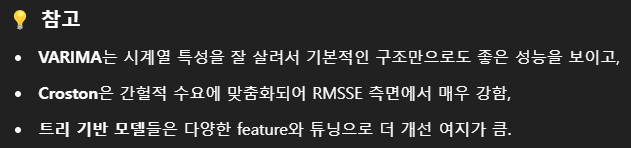